# ForecastLLM - Week 6 Day 3: Baselines and Evaluation

This week - build a model that predicts future values from historical data.

# Order of play

DAY 1: Data Curation  
DAY 2: Data Pre-processing  
DAY 3: Baselines and Evaluation  
DAY 4: Deep Learning and LLMs  
DAY 5: Fine-tuning a Frontier Model  

## DAY 3: Baselines and Evaluation

Today we'll build simple forecasting baselines and evaluate them carefully.

These baseline scores become the benchmark that later models must beat.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from week6.data_loader import load_sample_series


In [2]:
TRAIN_FRACTION = 0.8
SEASONAL_PERIOD = 7

In [3]:
# Load and normalize to [timestamp, value]
def make_synthetic_series(periods=240):
    dates = pd.date_range("2024-01-01", periods=periods, freq="D")
    trend = np.linspace(100, 120, periods)
    weekly = 6 * np.sin(np.arange(periods) * 2 * np.pi / 7)
    noise = np.random.default_rng(42).normal(scale=1.0, size=periods)
    return pd.DataFrame({"timestamp": dates, "value": trend + weekly + noise})

try:
    loaded = load_sample_series()
except Exception as e:
    print(f"Loader failed ({e}); using synthetic fallback")
    loaded = None

if isinstance(loaded, pd.Series):
    ts_df = loaded.rename("value").to_frame().reset_index()
    if ts_df.shape[1] == 2:
        ts_df.columns = ["timestamp", "value"]
elif isinstance(loaded, pd.DataFrame):
    ts_df = loaded.copy()
else:
    ts_df = make_synthetic_series()

if "value" not in ts_df.columns:
    numeric_cols = ts_df.select_dtypes(include=[np.number]).columns.tolist()
    if numeric_cols:
        ts_df = ts_df.rename(columns={numeric_cols[0]: "value"})
    else:
        ts_df = make_synthetic_series()

if "timestamp" not in ts_df.columns:
    ts_df = ts_df.reset_index().rename(columns={ts_df.index.name or "index": "timestamp"})

ts_df = ts_df[["timestamp", "value"]].copy()
ts_df["value"] = pd.to_numeric(ts_df["value"], errors="coerce")
ts_df = ts_df.dropna(subset=["value"]).sort_values("timestamp").reset_index(drop=True)
ts_df["timestamp"] = pd.to_datetime(ts_df["timestamp"], errors="coerce")
if ts_df["timestamp"].isna().all():
    ts_df["timestamp"] = pd.RangeIndex(start=0, stop=len(ts_df), step=1)

# fallback again if loader returned placeholder/insufficient usable values
min_required = max(40, SEASONAL_PERIOD + 5)
if len(ts_df) < min_required:
    ts_df = make_synthetic_series()

split_idx = int(len(ts_df) * TRAIN_FRACTION)
train_df = ts_df.iloc[:split_idx].copy()
test_df = ts_df.iloc[split_idx:].copy()

print(f"Loaded {len(ts_df):,} observations")
print(f"Train rows: {len(train_df):,}, Test rows: {len(test_df):,}")


Loaded 240 observations
Train rows: 192, Test rows: 48


In [4]:
def naive_forecast(series, split_index):
    # one-step-ahead naive forecast: predict with previous observed value
    return series.shift(1).iloc[split_index:]


In [5]:
naive_pred = naive_forecast(ts_df["value"], split_idx)
naive_pred.head()

192    121.653312
193    118.287061
194    115.008769
195    109.277696
196    110.732276
Name: value, dtype: float64

In [6]:
# That was a first baseline. Let's add one that can handle weekly seasonality.
def seasonal_naive_forecast(series, split_index, seasonal_period=7):
    # one-step-ahead seasonal naive: use value from one full season earlier
    return series.shift(seasonal_period).iloc[split_index:]


In [7]:
seasonal_pred = seasonal_naive_forecast(ts_df["value"], split_idx, SEASONAL_PERIOD)
seasonal_pred.head()

192    119.620230
193    113.144786
194    108.574499
195    109.673069
196    117.466828
Name: value, dtype: float64

In [8]:
def mean_absolute_error(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return np.mean(np.abs(y_true - y_pred))


In [9]:
def smape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denominator = np.abs(y_true) + np.abs(y_pred)
    denominator = np.where(denominator == 0, 1e-9, denominator)
    return 100 * np.mean(2.0 * np.abs(y_true - y_pred) / denominator)


In [10]:
def evaluate_forecast(y_true, y_pred, model_name):
    frame = pd.DataFrame({"y_true": y_true, "y_pred": y_pred}).dropna()
    return {
        "model": model_name,
        "rows": len(frame),
        "mae": mean_absolute_error(frame["y_true"], frame["y_pred"]),
        "smape": smape(frame["y_true"], frame["y_pred"]),
    }


In [11]:
y_true_test = ts_df["value"].iloc[split_idx:]
naive_results = evaluate_forecast(y_true_test, naive_pred, "Naive")
naive_results

{'model': 'Naive',
 'rows': 48,
 'mae': np.float64(3.589241371524704),
 'smape': np.float64(3.042430517886128)}

In [12]:
seasonal_results = evaluate_forecast(y_true_test, seasonal_pred, "Seasonal Naive (period=7)")
seasonal_results

{'model': 'Seasonal Naive (period=7)',
 'rows': 48,
 'mae': np.float64(1.0617500351178266),
 'smape': np.float64(0.9055236915993874)}

In [13]:
results_df = pd.DataFrame([naive_results, seasonal_results])
results_df

,model,rows,mae,smape
0,Naive,48,3.589241,3.042431
1,Seasonal Naive (period=7),48,1.061750,0.905524


In [14]:
# Lower MAE and lower sMAPE are better
results_df.sort_values(["mae", "smape"]).reset_index(drop=True)

,model,rows,mae,smape
0,Seasonal Naive (period=7),48,1.061750,0.905524
1,Naive,48,3.589241,3.042431


In [15]:
comparison_df = pd.DataFrame({
    "timestamp": ts_df["timestamp"].iloc[split_idx:],
    "actual": y_true_test.values,
    "naive": naive_pred.values,
    "seasonal_naive": seasonal_pred.values,
})
comparison_df.head()

,timestamp,actual,naive,seasonal_naive
192,2024-07-11,118.287061,121.653312,119.620230
193,2024-07-12,115.008769,118.287061,113.144786
194,2024-07-13,109.277696,115.008769,108.574499
195,2024-07-14,110.732276,109.277696,109.673069
196,2024-07-15,117.045000,110.732276,117.466828


In [16]:
comparison_df.tail()

,timestamp,actual,naive,seasonal_naive
235,2024-08-23,116.407823,121.455809,115.622952
236,2024-08-24,111.752097,116.407823,113.026229
237,2024-08-25,114.978981,111.752097,113.092431
238,2024-08-26,118.853904,114.978981,118.739837
239,2024-08-27,124.161549,118.853904,124.420820


In [17]:
comparison_df["naive_abs_error"] = np.abs(comparison_df["actual"] - comparison_df["naive"])
comparison_df["seasonal_abs_error"] = np.abs(comparison_df["actual"] - comparison_df["seasonal_naive"])
comparison_df[["naive_abs_error", "seasonal_abs_error"]].describe()

,naive_abs_error,seasonal_abs_error
count,48.000000,48.000000
mean,3.589241,1.061750
std,1.820950,0.803015
min,0.018701,0.094013
25%,2.432409,0.541157
50%,3.448879,0.901286
75%,5.060369,1.462738
max,7.853011,3.799191


In [18]:
print(f"Train shape: {train_df.shape}")
print(f"Test shape: {test_df.shape}")
print(comparison_df.head(10).to_string(index=False))

Train shape: (192, 2)
Test shape: (48, 2)
 timestamp     actual      naive  seasonal_naive  naive_abs_error  seasonal_abs_error
2024-07-11 118.287061 121.653312      119.620230         3.366251            1.333169
2024-07-12 115.008769 118.287061      113.144786         3.278291            1.863984
2024-07-13 109.277696 115.008769      108.574499         5.731073            0.703197
2024-07-14 110.732276 109.277696      109.673069         1.454579            1.059206
2024-07-15 117.045000 110.732276      117.466828         6.312725            0.421827
2024-07-16 120.781739 117.045000      122.314236         3.736739            1.532497
2024-07-17 122.413483 120.781739      121.653312         1.631744            0.760171
2024-07-18 119.092579 122.413483      118.287061         3.320904            0.805518
2024-07-19 114.470674 119.092579      115.008769         4.621905            0.538096
2024-07-20 112.377998 114.470674      109.277696         2.092676            3.100302


## Baseline visualization

A chronological split is required in forecasting because future values must never leak into training.

These two baselines are intentionally simple. If a more advanced method cannot beat them, it usually is not worth keeping.


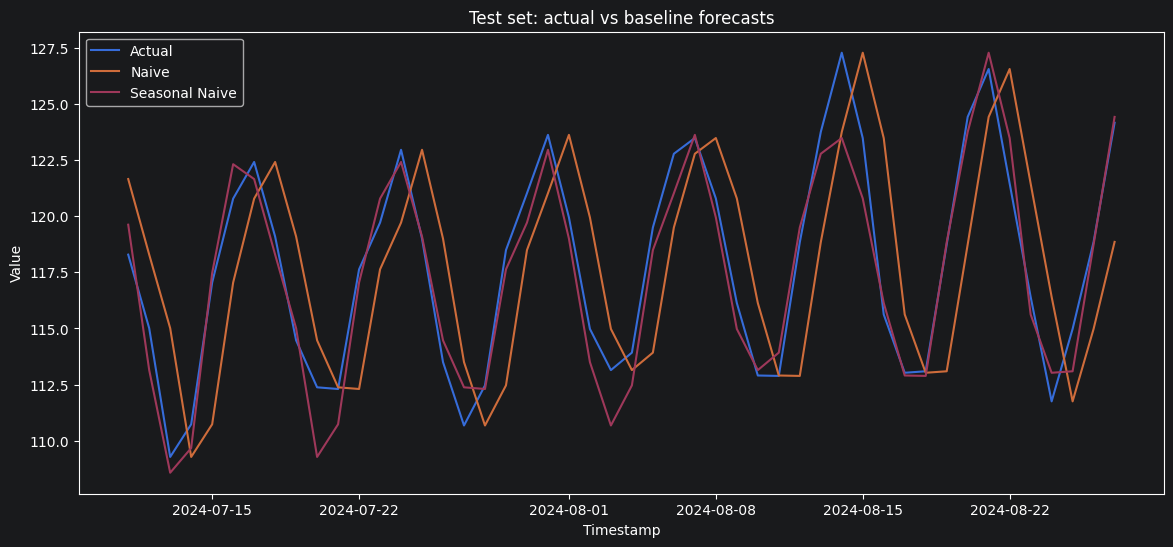

In [19]:
# Plot actual test values against both baselines
plot_df = comparison_df.dropna().copy()

plt.figure(figsize=(14, 6))
plt.plot(plot_df["timestamp"], plot_df["actual"], label="Actual")
plt.plot(plot_df["timestamp"], plot_df["naive"], label="Naive")
plt.plot(plot_df["timestamp"], plot_df["seasonal_naive"], label="Seasonal Naive")
plt.title("Test set: actual vs baseline forecasts")
plt.xlabel("Timestamp")
plt.ylabel("Value")
plt.legend()
plt.show()

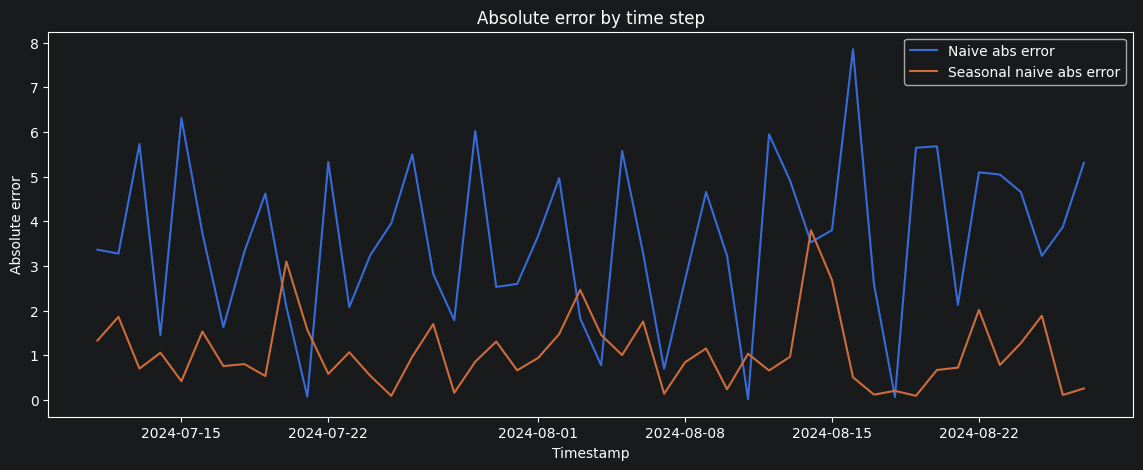

In [20]:
# Compare absolute errors over time
plt.figure(figsize=(14, 5))
plt.plot(plot_df["timestamp"], np.abs(plot_df["actual"] - plot_df["naive"]), label="Naive abs error")
plt.plot(plot_df["timestamp"], np.abs(plot_df["actual"] - plot_df["seasonal_naive"]), label="Seasonal naive abs error")
plt.title("Absolute error by time step")
plt.xlabel("Timestamp")
plt.ylabel("Absolute error")
plt.legend()
plt.show()

In [21]:
# TODO: compare learned models against baseline forecasts
best_baseline = results_df.sort_values(["mae", "smape"]).iloc[0]["model"]
print(f"Current best baseline: {best_baseline}")

Current best baseline: Seasonal Naive (period=7)


## Next models (deferred)

In the original pricing notebook, this section explored heavier traditional ML models.

For ForecastLLM Day 3, we stop at robust baselines and metrics so Day 4+ models have a clear benchmark.


In [22]:
# TODO: extend to multi-series M4 data
multi_series_ready = False
print(f"Multi-series mode enabled: {multi_series_ready}")

Multi-series mode enabled: False


In [23]:
# Keep a compact artifact for later notebooks
artifacts = {
    "train_rows": len(train_df),
    "test_rows": len(test_df),
    "seasonal_period": SEASONAL_PERIOD,
    "metrics": results_df.to_dict(orient="records"),
}
artifacts

{'train_rows': 192,
 'test_rows': 48,
 'seasonal_period': 7,
 'metrics': [{'model': 'Naive',
   'rows': 48,
   'mae': 3.589241371524704,
   'smape': 3.042430517886128},
  {'model': 'Seasonal Naive (period=7)',
   'rows': 48,
   'mae': 1.0617500351178266,
   'smape': 0.9055236915993874}]}

In [24]:
# TODO: add rolling-origin evaluation later
rolling_origin_planned = True
print(f"Rolling-origin evaluation planned: {rolling_origin_planned}")

Rolling-origin evaluation planned: True


In [25]:
print("Final baseline table:")
print(results_df.to_string(index=False))

Final baseline table:
                    model  rows      mae    smape
                    Naive    48 3.589241 3.042431
Seasonal Naive (period=7)    48 1.061750 0.905524


<table style="margin: 0; text-align: left;">
    <tr>
        <td style="width: 150px; height: 150px; vertical-align: middle;">
            <img src="../assets/business.jpg" width="150" height="150" style="display: block;" />
        </td>
        <td>
            <h2 style="color:#181;">Business applications</h2>
            <span style="color:#181;">Baseline forecasting is operationally important: it gives a transparent minimum bar,
            helps detect when advanced models are not adding value, and keeps evaluation grounded in realistic time-ordering.</span>
        </td>
    </tr>
</table>

Later notebooks can compare richer ML and LLM-assisted approaches against these baseline forecasts.